# 🧠 Self-RAG with Web Fallback

A smart question-answering system that **thinks before it searches** — using LangGraph to decide the best way to answer each question.

---

## 💡 What Does This Do?

Instead of always searching documents (like basic RAG), this pipeline is smarter:

- If the question is **simple** → answer from memory directly
- If the question needs **specific facts** → search company documents
- If documents **don't have the answer** → search the web automatically

---

## 🔄 How It Works (Step by Step)

```
Question Asked
     ↓
[1] Do I need to search?
     ├── NO  → Answer directly from LLM memory ✅
     └── YES ↓
[2] Search company documents (PDF vector store)
     ↓
[3] Are the results relevant?
     ├── YES → Generate answer from documents ✅
     └── NO  ↓
[4] Rewrite question as a web search query
     ↓
[5] Search the web (Tavily)
     ↓
[6] Are web results relevant?
     └── YES → Generate answer from web results ✅
```

---

## 🛠️ Tools & Libraries Used

| Purpose | Tool |
|---|---|
| Graph / Flow Control | LangGraph |
| LLM | Groq → `llama-3.3-70b-versatile` |
| Embeddings | HuggingFace `all-MiniLM-L6-v2` |
| Document Store | FAISS (in-memory vector store) |
| Web Search | Tavily Search API |
| PDF Loading | LangChain `PyPDFLoader` |

---

## 📄 Data Sources

Three company PDF files are loaded and indexed:

- `company_policy.pdf`
- `company_profile.pdf`
- `product_launch_pricing.pdf`

---



## 🔑 Key Concept

> **Self-RAG** = The model grades its own retrieval results and decides what to do next, rather than blindly using whatever it finds.

In [1]:
## Imports tools like PDF loader, vector store, text splitter, LLM, and graph builder.

from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
## Load PDFs Reads 3 company PDF files: company policy, company profile, and product pricing.

docs = (
    PyPDFLoader(r"D:\Education\Machine Learning\Machine learning Project\AGENTICLANGGRAPH\8-RAG\Data\company_policy.pdf").load()
    + PyPDFLoader(r"D:\Education\Machine Learning\Machine learning Project\AGENTICLANGGRAPH\8-RAG\Data\company_profile.pdf").load()
    + PyPDFLoader(r"D:\Education\Machine Learning\Machine learning Project\AGENTICLANGGRAPH\8-RAG\Data\product_launch_pricing.pdf").load()
)

In [3]:
## Split into chunks
## Cuts the PDF text into small pieces (600 characters each) so they're easier to search.

chunks = RecursiveCharacterTextSplitter(
    chunk_size=600, chunk_overlap=150
).split_documents(docs)

In [4]:
## Create embeddings
## Embeddings are like turning text into numbers so the computer can understand and compare them. Here, we use a model called "sentence-transformers/all-MiniLM-L6-v2" to create these embeddings for our text chunks.
from langchain_huggingface import HuggingFaceEmbeddings

embd = HuggingFaceEmbeddings(
        model_name="sentence-transformers/all-MiniLM-L6-v2",
        model_kwargs={'device': 'cpu'},
        encode_kwargs={'normalize_embeddings': True}
    )

print(embd.embed_query("hello world"))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[-0.034477297216653824, 0.031023187562823296, 0.006734919734299183, 0.026108957827091217, -0.03936200961470604, -0.16030246019363403, 0.06692399084568024, -0.006441456265747547, -0.047450486570596695, 0.014758874662220478, 0.07087532430887222, 0.055527616292238235, 0.019193338230252266, -0.026251329109072685, -0.01010952703654766, -0.02694045379757881, 0.022307459264993668, -0.02222668193280697, -0.14969265460968018, -0.017493000254034996, 0.007676252163946629, 0.05435226857662201, 0.0032544017303735018, 0.031725894659757614, -0.08462140709161758, -0.029405973851680756, 0.05159560218453407, 0.04812406376004219, -0.0033148550428450108, -0.05827920883893967, 0.04196922853589058, 0.02221068926155567, 0.1281888484954834, -0.02233894169330597, -0.011656275950372219, 0.06292840093374252, -0.03287636116147041, -0.09122602641582489, -0.03117535077035427, 0.05269957333803177, 0.04703487455844879, -0.0842030718922615, -0.030056193470954895, -0.02074483223259449, 0.009517823345959187, -0.00372179

In [5]:
##Build vector store :Stores all the chunks as vectors in FAISS (a fast search database). Sets up a retriever to find top 4 relevant chunks. 
vectorstore = FAISS.from_documents(chunks, embd)
retriever = vectorstore.as_retriever(search_kwargs={"k": 4})

In [6]:
from langchain_groq import ChatGroq
import os 

#os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


llm=ChatGroq(model="llama-3.3-70b-versatile")
#llm = ChatOpenAI(model="gpt-4o")
result=llm.invoke("Hello")
result

AIMessage(content='Hello. How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 36, 'total_tokens': 46, 'completion_time': 0.026120665, 'prompt_time': 0.005206806, 'queue_time': 0.206809245, 'total_time': 0.031327471}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_d42c28f9ce', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019daf47-eef9-7553-ab3d-e5c142aa2b54-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 10, 'total_tokens': 46})

In [ ]:
#Define State :A shared memory/container that holds everything during the process: the question, retrieved docs, answer, and quality checks.
class State(TypedDict):
    question: str

    # ✅ NEW: what we actually send to vector retriever
    retrieval_query: str
    rewrite_tries: int
    
    need_retrieval: bool
    docs: List[Document]
    relevant_docs: List[Document]
    context: str
    answer: str
    web_query: str

In [ ]:
# Step 1: Decide if retrieval is needed

class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)


# IMPORTANT: no `.content` for structured output
should_retrieve_llm = llm.with_structured_output(RetrieveDecision)

def decide_retrieval(state: "State"):
    decision: RetrieveDecision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state["question"])
    )
    return {"need_retrieval": decision.should_retrieve}


def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    return "retrieve" if state["need_retrieval"] else "generate_direct"

In [35]:
# Direct Generation  Answer Prompt if question can be answered without retrieval 
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)


def generate_direct(state: State):
    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question=state["question"]
        )
    )
    return {
        "answer": out.content
    }

In [36]:
def retrieve(state: State):
    return {"docs": retriever.invoke(state["question"])}

In [37]:
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business RAG assistant.\n"
            "Answer the user's question using ONLY the provided context.\n"
            "If the context does not contain enough information, say:\n"
            "'No relevant document found.'\n"
            "Do not use outside knowledge.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

def generate_from_context(state: State):
    # Stuff relevant docs into one block
    context = "\n\n---\n\n".join(
        [d.page_content for d in state.get("relevant_docs", [])]
    ).strip()

    if not context:
        return {"answer": "No relevant document found.", "context": ""}

    out = llm.invoke(
        rag_generation_prompt.format_messages(
            question=state["question"],
            context=context
        )
    )
    return {"answer": out.content, "context": context}

In [39]:
question = "Tell me about the company policy?"

route = decide_retrieval({"question": question})

if route["need_retrieval"]:

    retrieved_docs = retriever.invoke(question)

    result = generate_from_context({
        "question": question,
        "relevant_docs": retrieved_docs
    })

    print("Retrieved Answer:", result["answer"])

else:
    direct_answer = generate_direct({"question": question})
    print("Direct Answer:", direct_answer)

Retrieved Answer: The company policy, as outlined in the Employee Policy Handbook (Version 1.0, effective January 2026), includes the following key points:

1. **Remote Work Policy**: AdilTech supports a hybrid and remote-first work culture. Remote employees must maintain a professional workspace, have a reliable internet connection, and use secure devices and VPN connections. Regular check-ins with team leads and attending video meetings with camera on are mandatory.

2. **Performance & Appraisal**: Performance reviews are conducted bi-annually (June and December).

3. **Confidentiality & Data Security**: Employees must sign a Non-Disclosure Agreement (NDA) and not share client data, proprietary algorithms, or business strategies with third parties. All project-related work must be stored on company-approved platforms.

4. **Intellectual Property**: All work products created during employment belong to the company.

5. **Code of Conduct**: Not fully specified in the provided context, 

In [ ]:
# pip install -U langchain-tavily

Note: you may need to restart the kernel to use updated packages.


In [28]:
from langchain_tavily import TavilySearch
## web search
tavily_key = os.getenv("TAVILY_API_KEY")
if tavily_key is None:
    print("Error: TAVILY_API_KEY not found in environment variables")
else:
    os.environ["TAVILY_API_KEY"] = tavily_key


from langchain_community.tools.tavily_search import TavilySearchResults

web_search_tool = TavilySearchResults(k=3)

In [29]:
class WebQuery(BaseModel):
    query: str

rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user question into a web search query composed of keywords.\n"
            "Rules:\n"
            "- Keep it short (6–14 words).\n"
            "- If the question implies recency, add (last 30 days).\n"
            "- Do NOT answer the question.\n"
            "- Return JSON with a single key: query",
        ),
        ("human", "Question: {question}"),
    ]
)

rewrite_chain = rewrite_prompt | llm.with_structured_output(WebQuery)

def rewrite_query_node(state: State):
    out = rewrite_chain.invoke({"question": state["question"]})
    return {"web_query": out.query}

tavily = TavilySearchResults(max_results=5)

def web_search_node(state: State):
    q = state.get("web_query") or state["question"]
    results = tavily.invoke({"query": q})

    docs = []
    for r in results or []:
        title = r.get("title", "")
        url = r.get("url", "")
        content = r.get("content", "") or r.get("snippet", "")
        text = f"TITLE: {title}\nURL: {url}\nCONTENT:\n{content}"
        docs.append(
            Document(
                page_content=text,
                metadata={"source": "web", "url": url, "title": title},
            )
        )

    return {"docs": docs}

In [40]:
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description="True if the document helps answer the question, else False."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance.\n"
            "Return JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        ),
    ]
)

relevance_llm = llm.with_structured_output(RelevanceDecision)

def is_relevant(state: State):
    
    relevant_docs: List[Document] = []

    for doc in state["docs"]:
        decision: RelevanceDecision = relevance_llm.invoke(
            is_relevant_prompt.format_messages(
                question=state["question"],
                document=doc.page_content
            )
        )

        if decision.is_relevant:
            relevant_docs.append(doc)

    return {"relevant_docs": relevant_docs}

In [41]:
def no_relevant_docs(state: State):
    return {"answer": "No relevant document found.", "context": ""}

In [42]:
def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    if state["need_retrieval"]:
        return "retrieve"
    return "generate_direct"

In [43]:
def route_after_relevance(state: State) -> Literal["generate_from_context", "rewrite_query"]:
    if state.get("relevant_docs") and len(state["relevant_docs"]) > 0:
        return "generate_from_context"
    return "rewrite_query"

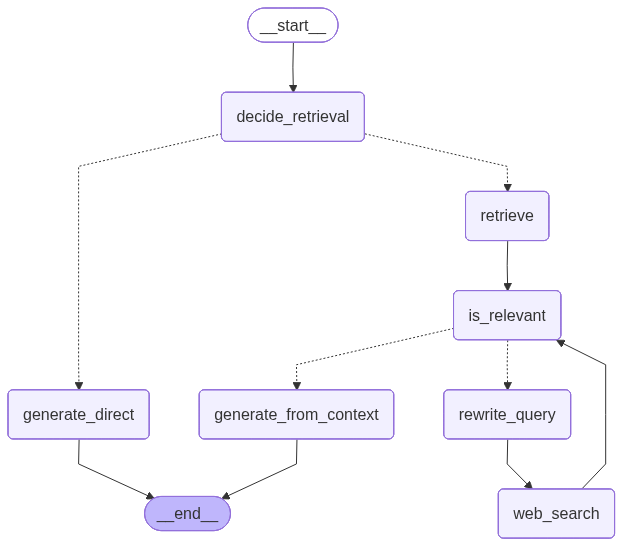

In [44]:
graph = StateGraph(State)

graph.add_node(
    "decide_retrieval",
    decide_retrieval,
    description="Decide if retrieval is needed to answer the question."
)

graph.add_node(
    "generate_direct",
    generate_direct,
    description="Generate an answer directly without retrieval."
)
graph.add_node(
    "retrieve",
    retrieve,
    description="Retrieve relevant documents using the retriever."
)

graph.add_node(
    "is_relevant",
    is_relevant,
    description="Judge the relevance of retrieved documents to the question."
)

graph.add_node(
    "rewrite_query",
    rewrite_query_node,
    description="Rewrite the question into a web search query."
)



graph.add_node(
    "web_search",
    web_search_node,
    description="Perform a web search using the rewritten query."
)
graph.add_node(
    "generate_from_context",
    generate_from_context,
    description="Generate an answer using the retrieved documents as context."
)

graph.add_edge(START,"decide_retrieval")
graph.add_conditional_edges("decide_retrieval", route_after_decide,{"generate_direct": "generate_direct", "retrieve": "retrieve",},)
graph.add_edge("retrieve","is_relevant")
graph.add_conditional_edges("is_relevant", route_after_relevance,{"generate_from_context": "generate_from_context", "rewrite_query": "rewrite_query",},)
graph.add_edge("rewrite_query","web_search")
graph.add_edge("web_search","is_relevant")
graph.add_edge("generate_direct", END)
graph.add_edge("generate_from_context", END)

app=graph.compile()
app


In [46]:
result = app.invoke(
    {
        "question": "Who won the Aus vs Zim World T20 match 2026 and who was the top scorer",
        "docs": [],
        "relevant_docs": [],
        "context": "",
        "answer": "",
    }
)

print(result["answer"])

Zimbabwe won the Aus vs Zim World T20 match 2026 by 23 runs. The top scorer for Australia was Matt Renshaw with 65 runs, while for Zimbabwe, Brian Bennett scored an unbeaten 64.


In [47]:
result = app.invoke(
    {
        "question": "Tell me about the company policy?",
        "docs": [],
        "relevant_docs": [],
        "context": "",
        "answer": "",
    }
)

print(result["answer"])

The company policy at AdilTech AI Solutions includes the following key points:

1. **Remote Work Policy**: Supports a hybrid and remote-first work culture for eligible roles, with requirements for a professional workspace, reliable internet, secure devices, and regular check-ins.
2. **Performance & Appraisal**: Conducts bi-annual performance reviews.
3. **Confidentiality & Data Security**: Requires employees to sign a Non-Disclosure Agreement, prohibits sharing of client data and proprietary information, and mandates use of company-approved platforms for project work.
4. **Intellectual Property**: States that all work products created during employment belong to the company.
5. **Code of Conduct**: Although not fully detailed in the provided context, it is mentioned as part of the employee policy handbook.
6. **Policy Updates**: The company reserves the right to update policies, with significant changes notified to employees at least 14 days in advance.

These policies apply to all ful